# Week 2 — Baseline Forecasts

Source: the Week 1 canonical table, `data/processed/gb_energy_2020_2025.parquet` (`edf.data.clean`). Baselines are pure lags of `demand` (`edf.models.baselines`), scored per calendar year with the walk-forward harness (`edf.evaluate`).

**Scope:** only `TRAIN` (2020-2023) and `VALIDATION` (2024) years are evaluated here — `TEST` (2025, `edf.config.TEST`) stays untouched per PLAN.md's "don't peek at test data" rule. These numbers, on `VALIDATION`, are what Week 3's LightGBM model must beat.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from edf import config
from edf.evaluate import compare_models, yearly_folds
from edf.models.baselines import BASELINES

pd.options.display.float_format = "{:.1f}".format

In [2]:
df = pd.read_parquet("../data/processed/gb_energy_2020_2025.parquet")
demand = df["demand"]
demand.shape

(105216,)

## Compute every baseline, fold by calendar year

`previous_week_same_time` is the seasonal-naive baseline — its per-fold MAE becomes the MASE denominator for every other baseline (and, from Week 3 onward, every model).

In [3]:
predictions = {name: fn(demand) for name, fn in BASELINES.items()}

# Exclude TEST (2025) from the fold boundaries entirely.
test_start = pd.Timestamp(config.TEST[0], tz=demand.index.tz)
in_scope_index = demand.index[demand.index < test_start]
folds = yearly_folds(in_scope_index)

results = compare_models(
    demand, predictions, folds, seasonal_naive_name="previous_week_same_time"
)
results

mae   rmse  mape       n  mase
model                   year                                  
naive                   2020  690.5  933.9   2.6 17567.0   0.4
                        2021  698.3  930.5   2.5 17520.0   0.3
                        2022  672.0  896.2   2.5 17520.0   0.3
                        2023  664.0  884.5   2.6 17520.0   0.3
                        2024  657.2  881.3   2.5 17568.0   0.3
previous_day_same_time  2020 1849.2 2596.5   7.0 17520.0   0.9
                        2021 1762.2 2474.1   6.3 17520.0   0.9
                        2022 1852.0 2642.9   7.1 17520.0   0.9
                        2023 1830.8 2547.2   7.2 17520.0   0.9
                        2024 1901.9 2640.0   7.4 17568.0   0.9
previous_week_same_time 2020 1955.0 2556.9   7.4 17232.0   1.0
                        2021 1998.7 2694.7   7.1 17520.0   1.0
                        2022 2035.0 2804.6   7.7 17520.0   1.0
                        2023 2057.7 2734.2   7.9 17520.0   1.0
                        2024 2027.9 2686.5   7.7 17568.0   1.0
trailing_moving_average 2020 2331.3 3000.3   8.9 17376.0   1.2
                        2021 2115.6 2744.2   7.6 17520.0   1.1
                        2022 2337.9 3026.9   9.1 17520.0   1.1
                        2023 2197.2 2851.8   8.7 17520.0   1.1
                        2024 2334.7 3005.9   9.1 17568.0   1.2

## Aggregate across TRAIN+VALIDATION years, and VALIDATION alone

The per-year table above is the full result; here it's collapsed two ways for readability: a straight mean across all in-scope years, and the single VALIDATION (2024) year in isolation — the number Week 3 is actually trying to beat.

In [4]:
overall = results.groupby("model")[["mae", "rmse", "mape", "mase"]].mean()
overall = overall.reindex(BASELINES.keys())
overall

,mae,rmse,mape,mase
model,,,,
naive,676.4,905.3,2.5,0.3
previous_day_same_time,1839.2,2580.1,7.0,0.9
previous_week_same_time,2014.9,2695.4,7.6,1.0
trailing_moving_average,2263.3,2925.8,8.7,1.1


In [5]:
validation_year = int(config.VALIDATION[0][:4])
validation_only = results.xs(validation_year, level="year").reindex(BASELINES.keys())
validation_only

,mae,rmse,mape,n,mase
model,,,,,
naive,657.2,881.3,2.5,17568.0,0.3
previous_day_same_time,1901.9,2640.0,7.4,17568.0,0.9
previous_week_same_time,2027.9,2686.5,7.7,17568.0,1.0
trailing_moving_average,2334.7,3005.9,9.1,17568.0,1.2


## Finding: at half-hourly resolution, persistence beats seasonality

`naive` (last observed half-hour) scores **MASE ≈ 0.32-0.35**, far below `previous_week_same_time` (MASE = 1.0 by construction) and even below `previous_day_same_time` (MASE ≈ 0.88-0.95). `trailing_moving_average` (mean of the last 4 same-half-hour-of-day values) is *worse* than a single week-ago observation, not better — averaging in day-to-day demand-level drift hurts more than it smooths noise, at this lag.

This makes physical sense: GB demand barely moves in 30 minutes, so "what was it a moment ago" is a very strong predictor — far stronger than "what was it this time last week", which has to survive a full week of trend/weather drift. But it's a **scale caveat for later weeks, not a win to declare now**: NESO's own benchmark (`edf.data.demand_forecast_benchmark`) is a genuine *day-ahead* forecast, not a 30-minutes-ahead one. A future model evaluated at t-1 lead time is solving an easier problem than NESO's day-ahead forecast and isn't directly comparable to it — Week 3 needs to fix an explicit forecast horizon (day-ahead, matching NESO's benchmark, seems the operationally relevant choice) before that comparison is drawn, rather than defaulting to whatever lag features happen to be included.

## Plot: MASE by year, one line per baseline

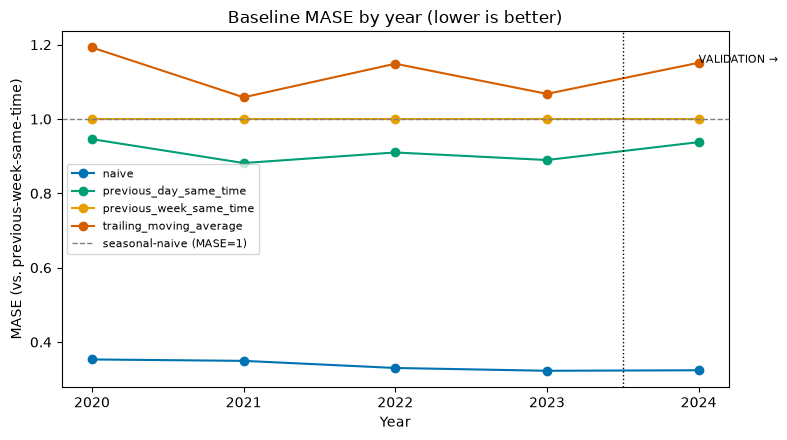

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = {
    "naive": "#0072B2",
    "previous_day_same_time": "#009E73",
    "previous_week_same_time": "#E69F00",
    "trailing_moving_average": "#D55E00",
}  # Okabe-Ito colorblind-safe palette, consistent with notebook 01

for model in BASELINES:
    series = results.xs(model, level="model")["mase"]
    ax.plot(series.index, series.values, marker="o", label=model, color=colors[model])

ax.axhline(1.0, color="grey", linestyle="--", linewidth=1, label="seasonal-naive (MASE=1)")
ax.axvline(
    int(config.VALIDATION[0][:4]) - 0.5, color="black", linestyle=":", linewidth=1
)
ax.text(
    int(config.VALIDATION[0][:4]), ax.get_ylim()[1] * 0.95, "VALIDATION →",
    fontsize=8, ha="left", va="top",
)
ax.set_title("Baseline MASE by year (lower is better)")
ax.set_xlabel("Year")
ax.set_ylabel("MASE (vs. previous-week-same-time)")
ax.set_xticks(sorted(demand.index[demand.index < test_start].year.unique()))
ax.legend(fontsize=8)
fig.tight_layout()